---
title: SP500 Review
author: Samantha Pang
date: 2025-12-01
date-modified: last-modified 
format: 
    html: 
        toc: true
        code-fold: true
---


In [2]:
import yfinance as yf
import numpy as np

# SP500 index
df = yf.download("^GSPC", period="1y")["Close"]
# today/yesterday price ratio / gross return
# log returns turn multiplicative processes into additive processes, making them easier to analyze statistically
returns = np.log(df/df.shift(1)).dropna()

C:\Users\neh2k\AppData\Local\Temp\ipykernel_12632\1337523686.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^GSPC", period="1y")["Close"]
[*********************100%***********************]  1 of 1 completed


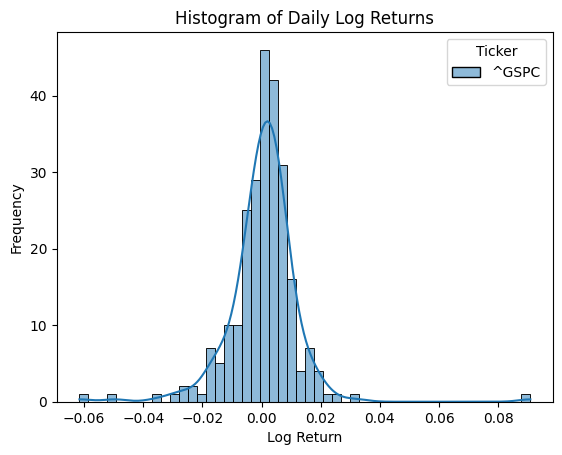

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=returns, kde=True, bins=50)
plt.title("Histogram of Daily Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()

Histogram shows a normal distribution of the logarithm return of SP500 over 1 year, which provides an insight into SP500's performance and volatility. Majority of returns cluster around the mean indicates smaller data movement. probability of extreme returns (both positive and negative) is low, suggesting limited risk of significant losses or gains within this period. Overall, the histogram suggests that SP500 has relatively stable performance with moderate volatility over the year.

In [12]:
returns.columns = ["Log Return"]
print('Approximate total return over past 1 year: ',returns['Log Return'].sum().round(4))
print('Annualizing volatility: ', (returns['Log Return'].std() * np.sqrt(252)).round(4))  # 252 trading days in a year/ sample size

Approximate total return over past 1 year:  0.1239
Annualizing volatility:  0.1895


since the distribution appears normal, we can use mean and standard deviation to summarize the data.
~68% of daily returns fall within ±1 × std() of the mean
~95% within ±2 × std()
~99.7% within ±3 × std()

Annualized volatility (daily × √252)
Low: 5–10% → bonds, very stable ETFs
Medium: 15–20% → S&P 500 historically
High: 30–80% → tech stocks, small-cap, crypto